# 05. Evaluación en Test

Evalúa los modelos **ya entrenados** contra el **test set**: los chips que nunca se usaron ni en entrenamiento ni en validación.

Busca checkpoints (`*_best.pt`) en `data/06_models/` **y sus subcarpetas**, así que sirve sin importar de cuál notebook de entrenamiento vengan:

| Carpeta | Notebook de origen |
|---|---|
| `data/06_models/*_best.pt` | `04_training_models.ipynb` (preentrenado, original) |
| `data/06_models/scratch/*_best.pt` | `04b_training_models_scratch.ipynb` (sin preentrenar) |
| `data/06_models/tuned/*_best.pt` | `04c_training_models_tuned.ipynb` (preentrenado, LR/paciencia ajustados) |

Esto da el número "real" de qué tan bien funciona cada modelo/variante con datos nuevos.

Resultados en texto/CSV → `data/08_reporting/`

## 1. Configuración

In [2]:
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src.data.dataset import create_dataloaders
from src.models.train import create_model
from src.utils.helpers import get_device, set_seed
from src.utils.metrics import compute_metrics

DATA_DIR = ROOT / "data"
MODELS_DIR = DATA_DIR / "06_models"
FIGURES_DIR = ROOT / "reports" / "figures"
REPORT_DIR = DATA_DIR / "08_reporting"

BATCH_SIZE = 32
NUM_WORKERS = 0
SEED = 42
LABELS = ["sem_garimpo", "com_garimpo"]

REPORT_DIR.mkdir(parents=True, exist_ok=True)

set_seed(SEED)
device = get_device()
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else str(device)

print(f"Device: {device}")
print(f"GPU: {gpu_name}")
print(f"PyTorch: {torch.__version__}")

c:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 5060
PyTorch: 2.12.0.dev20260408+cu128


In [3]:
!pip install seaborn


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Test DataLoader

Son los chips reservados en `02_preprocessing.ipynb` que ningún modelo vio durante `04_training_models.ipynb`.

In [4]:
loaders = create_dataloaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
test_loader = loaders["test"]

print(f"Test: {len(test_loader.dataset):,} chips | {len(test_loader):,} batches")

Test: 14,806 chips | 463 batches


## 3. Checkpoints disponibles

Busca automáticamente todos los `*_best.pt` en `data/06_models/` **incluyendo subcarpetas** (`scratch/`, `tuned/`, etc.). No importa cuántos haya: cada uno se evalúa por separado, y se identifica por su "variante" (la subcarpeta donde está, o "original" si está directo en `data/06_models/`).

In [5]:
# Si algún .pt no se detecta solo (nombre/ruta distinta, quedó en otro lado, etc.),
# agrega aquí su ruta relativa a data/06_models/ (puede incluir subcarpeta):
MANUAL_CHECKPOINTS = [
    # "resnet50_best.pt",
    # "tuned/resnet50_best.pt",
    # "scratch/resnet50_best.pt",
]


def get_variant(ckpt_path: Path, models_dir: Path) -> str:
    """'original' si el .pt está directo en models_dir, o el nombre de la subcarpeta."""
    rel_parent = ckpt_path.relative_to(models_dir).parent
    return "original" if str(rel_parent) == "." else str(rel_parent)


checkpoint_paths = sorted(MODELS_DIR.rglob("*_best.pt"))
for name in MANUAL_CHECKPOINTS:
    path = MODELS_DIR / name
    if path not in checkpoint_paths:
        checkpoint_paths.append(path)

print(f"Checkpoints encontrados: {len(checkpoint_paths)}")
for p in checkpoint_paths:
    variant = get_variant(p, MODELS_DIR) if p.exists() else "?"
    print(f"  - [{variant}] {p.name}" + ("  (⚠️ no existe)" if not p.exists() else ""))

if not checkpoint_paths:
    print(
        "\n⚠️  No hay checkpoints en data/06_models/ (ni en sus subcarpetas).\n"
        "Corre 04_training_models.ipynb primero, o copia ahí los .pt ya entrenados."
    )

Checkpoints encontrados: 12
  - [original] efficientnet_b0_best.pt
  - [original] resnet50_best.pt
  - [scratch] efficientnet_b0_best.pt
  - [scratch] resnet50_best.pt
  - [scratch] swin_tiny_patch4_window7_224_best.pt
  - [scratch] vit_tiny_patch16_224_best.pt
  - [original] swin_tiny_patch4_window7_224_best.pt
  - [tuned] efficientnet_b0_best.pt
  - [tuned] resnet50_best.pt
  - [tuned] swin_tiny_patch4_window7_224_best.pt
  - [tuned] vit_tiny_patch16_224_best.pt
  - [original] vit_tiny_patch16_224_best.pt


## 4. Helpers de evaluación

In [6]:
@torch.no_grad()
def evaluate_checkpoint(ckpt_path: Path, loader, device) -> dict:
    """Carga un checkpoint y corre inferencia completa sobre `loader`."""
    ckpt = torch.load(ckpt_path, map_location=device)
    model_name = ckpt["model_name"]
    img_size = ckpt.get("img_size", 128)

    model = create_model(model_name, img_size=img_size, pretrained=False).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.tolist())

    metrics = compute_metrics(all_labels, all_preds)
    metrics.update(
        {
            "model_name": model_name,
            "train_best_epoch": ckpt.get("epoch"),
            "y_true": all_labels,
            "y_pred": all_preds,
        }
    )
    return metrics


def plot_confusion_matrix(y_true, y_pred, title: str, save_path: Path) -> None:
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=LABELS, yticklabels=LABELS, ax=ax,
    )
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    ax.set_title(title)
    plt.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

## 5. Evaluar cada checkpoint en test


[1/12] Evaluando: [original] efficientnet_b0_best.pt
accuracy 0.8385 | macro F1 0.7748 | recall com_garimpo 0.8016 | precision com_garimpo 0.5539


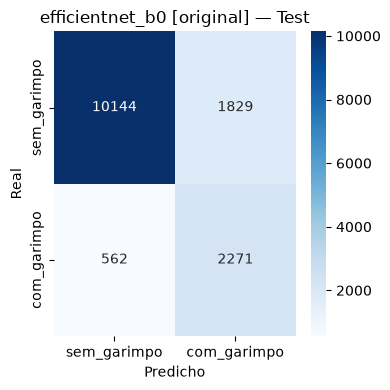


[2/12] Evaluando: [original] resnet50_best.pt
accuracy 0.8416 | macro F1 0.7765 | recall com_garimpo 0.7889 | precision com_garimpo 0.5613


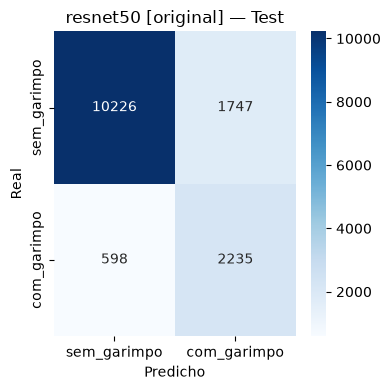


[3/12] Evaluando: [scratch] efficientnet_b0_best.pt
accuracy 0.8701 | macro F1 0.8037 | recall com_garimpo 0.7536 | precision com_garimpo 0.6354


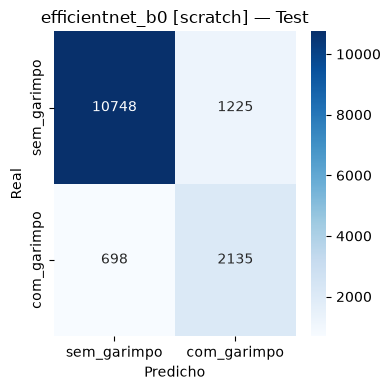


[4/12] Evaluando: [scratch] resnet50_best.pt
accuracy 0.8777 | macro F1 0.8076 | recall com_garimpo 0.7166 | precision com_garimpo 0.6682


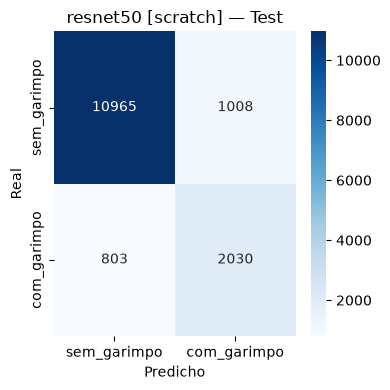


[5/12] Evaluando: [scratch] swin_tiny_patch4_window7_224_best.pt
accuracy 0.1913 | macro F1 0.1606 | recall com_garimpo 1.0000 | precision com_garimpo 0.1913


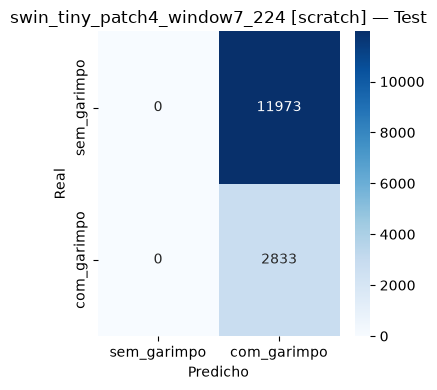


[6/12] Evaluando: [scratch] vit_tiny_patch16_224_best.pt
accuracy 0.7903 | macro F1 0.7194 | recall com_garimpo 0.7515 | precision com_garimpo 0.4700


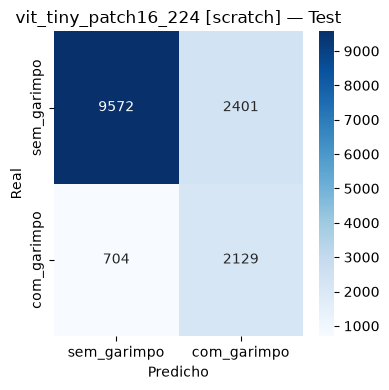


[7/12] Evaluando: [original] swin_tiny_patch4_window7_224_best.pt
accuracy 0.8278 | macro F1 0.7678 | recall com_garimpo 0.8348 | precision com_garimpo 0.5318


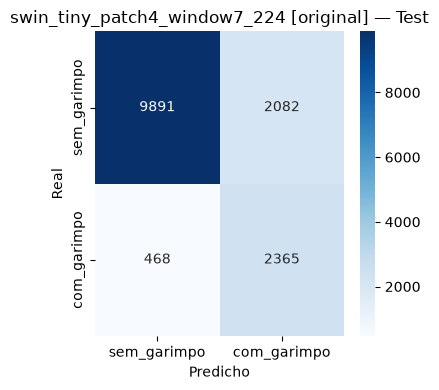


[8/12] Evaluando: [tuned] efficientnet_b0_best.pt
accuracy 0.8359 | macro F1 0.7736 | recall com_garimpo 0.8136 | precision com_garimpo 0.5479


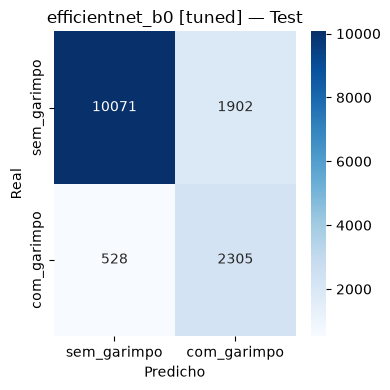


[9/12] Evaluando: [tuned] resnet50_best.pt
accuracy 0.8292 | macro F1 0.7641 | recall com_garimpo 0.7939 | precision com_garimpo 0.5362


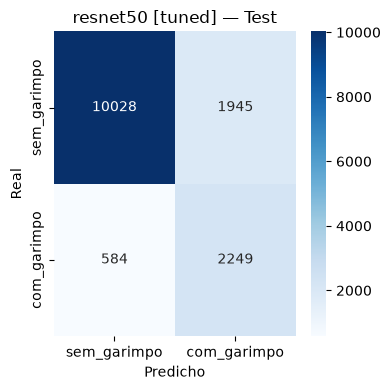


[10/12] Evaluando: [tuned] swin_tiny_patch4_window7_224_best.pt
accuracy 0.8484 | macro F1 0.7879 | recall com_garimpo 0.8214 | precision com_garimpo 0.5723


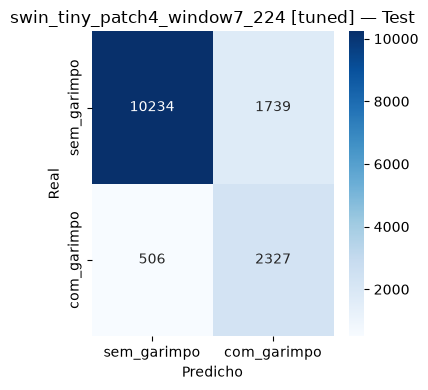


[11/12] Evaluando: [tuned] vit_tiny_patch16_224_best.pt
accuracy 0.8730 | macro F1 0.8080 | recall com_garimpo 0.7614 | precision com_garimpo 0.6416


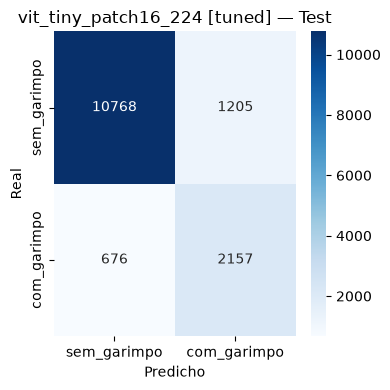


[12/12] Evaluando: [original] vit_tiny_patch16_224_best.pt
accuracy 0.8657 | macro F1 0.8002 | recall com_garimpo 0.7660 | precision com_garimpo 0.6209


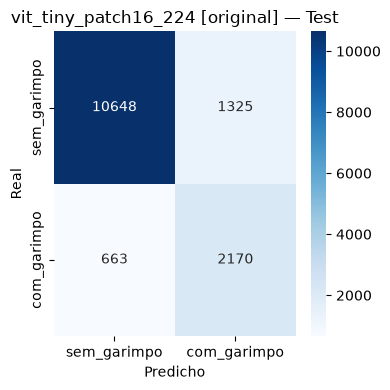


Evaluación completada.


In [7]:
results = []
log_lines = [
    "EVALUACIÓN EN TEST — RESULTADOS",
    f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M')}",
    f"Device: {device} | GPU: {gpu_name}",
    f"Test chips: {len(test_loader.dataset):,}",
    "",
]

for i, ckpt_path in enumerate(checkpoint_paths, start=1):
    variant = get_variant(ckpt_path, MODELS_DIR) if ckpt_path.exists() else "?"

    print("\n" + "=" * 60)
    print(f"[{i}/{len(checkpoint_paths)}] Evaluando: [{variant}] {ckpt_path.name}")
    print("=" * 60)

    if not ckpt_path.exists():
        print(f"⚠️  Saltado: no existe {ckpt_path}")
        continue

    m = evaluate_checkpoint(ckpt_path, test_loader, device)
    label = f"{m['model_name']} [{variant}]"

    print(
        f"accuracy {m['accuracy']:.4f} | macro F1 {m['macro_f1']:.4f} | "
        f"recall com_garimpo {m['recall_com_garimpo']:.4f} | "
        f"precision com_garimpo {m['precision_com_garimpo']:.4f}"
    )

    fig_name = f"{ckpt_path.stem.replace('_best', '')}_{variant}"
    plot_confusion_matrix(
        m["y_true"], m["y_pred"],
        title=f"{label} — Test",
        save_path=FIGURES_DIR / f"{fig_name}_test_confusion.png",
    )

    log_lines += [
        f"MODELO: {label} ({ckpt_path.name})",
        f"  test accuracy: {m['accuracy']:.4f}",
        f"  test macro F1: {m['macro_f1']:.4f}",
        f"  f1 com_garimpo: {m['f1_com_garimpo']:.4f} | f1 sem_garimpo: {m['f1_sem_garimpo']:.4f}",
        f"  recall com_garimpo: {m['recall_com_garimpo']:.4f} | precision com_garimpo: {m['precision_com_garimpo']:.4f}",
        "",
    ]

    results.append({
        "model": m["model_name"],
        "variant": variant,
        "checkpoint": ckpt_path.name,
        "train_best_epoch": m["train_best_epoch"],
        "test_accuracy": round(m["accuracy"], 4),
        "test_macro_f1": round(m["macro_f1"], 4),
        "test_f1_com_garimpo": round(m["f1_com_garimpo"], 4),
        "test_f1_sem_garimpo": round(m["f1_sem_garimpo"], 4),
        "test_recall_com_garimpo": round(m["recall_com_garimpo"], 4),
        "test_precision_com_garimpo": round(m["precision_com_garimpo"], 4),
    })

print("\nEvaluación completada.")

## 6. Resumen comparativo (¿qué tan bien funciona cada modelo de verdad?)

In [8]:
results_df = pd.DataFrame(results).sort_values("test_macro_f1", ascending=False)
display(results_df)

summary_csv = REPORT_DIR / "test_results_summary.csv"
results_df.to_csv(summary_csv, index=False)

best = results_df.iloc[0]
log_lines += [
    "=" * 60,
    "RESUMEN COMPARATIVO (test)",
    "=" * 60,
    "",
    results_df.to_string(index=False),
    "",
    f"MEJOR MODELO EN TEST: {best['model']} [{best['variant']}] | "
    f"test macro F1 = {best['test_macro_f1']} | accuracy = {best['test_accuracy']}",
    f"Checkpoint: {best['checkpoint']}",
]

summary_txt = REPORT_DIR / "test_results.txt"
summary_txt.write_text("\n".join(log_lines), encoding="utf-8")

print(f"\nArchivos guardados:")
print(f"  {summary_csv}")
print(f"  {summary_txt}")
print(f"\nMejor modelo en TEST: {best['model']} [{best['variant']}]")
print(f"  Accuracy:  {best['test_accuracy']*100:.1f}%")
print(f"  Macro F1:  {best['test_macro_f1']*100:.1f}%")

,model,variant,checkpoint,train_best_epoch,test_accuracy,test_macro_f1,test_f1_com_garimpo,test_f1_sem_garimpo,test_recall_com_garimpo,test_precision_com_garimpo
10,vit_tiny_patch16_224,tuned,vit_tiny_patch16_224_best.pt,5,0.8730,0.8080,0.6964,0.9197,0.7614,0.6416
3,resnet50,scratch,resnet50_best.pt,18,0.8777,0.8076,0.6915,0.9237,0.7166,0.6682
2,efficientnet_b0,scratch,efficientnet_b0_best.pt,41,0.8701,0.8037,0.6895,0.9179,0.7536,0.6354
11,vit_tiny_patch16_224,original,vit_tiny_patch16_224_best.pt,1,0.8657,0.8002,0.6858,0.9146,0.7660,0.6209
9,swin_tiny_patch4_window7_224,tuned,swin_tiny_patch4_window7_224_best.pt,2,0.8484,0.7879,0.6746,0.9012,0.8214,0.5723
1,resnet50,original,resnet50_best.pt,9,0.8416,0.7765,0.6559,0.8971,0.7889,0.5613
0,efficientnet_b0,original,efficientnet_b0_best.pt,8,0.8385,0.7748,0.6551,0.8946,0.8016,0.5539
7,efficientnet_b0,tuned,efficientnet_b0_best.pt,3,0.8359,0.7736,0.6548,0.8923,0.8136,0.5479
6,swin_tiny_patch4_window7_224,original,swin_tiny_patch4_window7_224_best.pt,7,0.8278,0.7678,0.6497,0.8858,0.8348,0.5318
8,resnet50,tuned,resnet50_best.pt,21,0.8292,0.7641,0.6401,0.8880,0.7939,0.5362



Archivos guardados:
  C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\test_results_summary.csv
  C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\test_results.txt

Mejor modelo en TEST: vit_tiny_patch16_224 [tuned]
  Accuracy:  87.3%
  Macro F1:  80.8%


## 7. Comparar val vs test (¿algún modelo se cae al pasar a datos nuevos?)

Como val y test son rasters distintos, comparar sus métricas ayuda a detectar sobreajuste a rasters específicos.

In [9]:
# Cada "variante" de entrenamiento guarda su propio resumen de validación.
# Se cruza cada checkpoint con el CSV de val que le corresponde según su variante.
VAL_SUMMARY_BY_VARIANT = {
    "original": REPORT_DIR / "training_results_summary.csv",
    "tuned": REPORT_DIR / "training_results_summary_tuned.csv",
    "scratch": REPORT_DIR / "training_results_summary_scratch.csv",
}

val_frames = []
for variant, path in VAL_SUMMARY_BY_VARIANT.items():
    if path.exists():
        vdf = pd.read_csv(path)[["timm_name", "val_macro_f1", "val_accuracy"]]
        vdf["variant"] = variant
        val_frames.append(vdf)

if val_frames:
    val_df = pd.concat(val_frames, ignore_index=True)
    comparison = results_df.merge(
        val_df, left_on=["model", "variant"], right_on=["timm_name", "variant"], how="left",
    ).drop(columns=["timm_name"])
    comparison["f1_drop_val_to_test"] = (
        comparison["val_macro_f1"] - comparison["test_macro_f1"]
    ).round(4)

    cols = ["model", "variant", "val_macro_f1", "test_macro_f1", "f1_drop_val_to_test",
            "val_accuracy", "test_accuracy"]
    display(comparison[cols].sort_values("f1_drop_val_to_test"))

    comparison_csv = REPORT_DIR / "val_vs_test_comparison.csv"
    comparison[cols].to_csv(comparison_csv, index=False)
    print(f"\nGuardado: {comparison_csv}")
else:
    print(
        "No se encontró ningún CSV de validación "
        "(training_results_summary[_tuned/_scratch].csv) para comparar."
    )

,model,variant,val_macro_f1,test_macro_f1,f1_drop_val_to_test,val_accuracy,test_accuracy
3,vit_tiny_patch16_224,original,0.7231,0.8002,-0.0771,0.7280,0.8657
1,resnet50,scratch,0.7462,0.8076,-0.0614,0.7524,0.8777
2,efficientnet_b0,scratch,0.7431,0.8037,-0.0606,0.7454,0.8701
0,vit_tiny_patch16_224,tuned,0.7529,0.8080,-0.0551,0.7606,0.8730
4,swin_tiny_patch4_window7_224,tuned,0.7536,0.7879,-0.0343,0.7547,0.8484
6,efficientnet_b0,original,0.7489,0.7748,-0.0259,0.7491,0.8385
8,swin_tiny_patch4_window7_224,original,0.7456,0.7678,-0.0222,0.7456,0.8278
7,efficientnet_b0,tuned,0.7566,0.7736,-0.0170,0.7609,0.8359
5,resnet50,original,0.7619,0.7765,-0.0146,0.7627,0.8416
10,vit_tiny_patch16_224,scratch,0.7163,0.7194,-0.0031,0.7270,0.7903



Guardado: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\val_vs_test_comparison.csv


## 8. Próximo paso

Con el mejor modelo identificado (mayor `test_macro_f1`), ya tienes evidencia lista para el informe: `data/08_reporting/test_results_summary.csv`, `test_results.txt`, `val_vs_test_comparison.csv`, y las matrices de confusión en `reports/figures/*_test_confusion.png`.